In [13]:
import pandas as pd
import numpy as  np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn. preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [2]:
data =pd.read_excel("customer_data.xlsx")
data.head()

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No


In [6]:
x_reg =data.drop(["CustomerID","Gender","City","Region","Purchase_Channel","Average_Purchase_Amount","Churn_Status","Date_of_Purchase"],axis=1)
y_reg =data["Average_Purchase_Amount"]
imputer = SimpleImputer(strategy='mean')
scaler=StandardScaler()
scaled_x_reg=scaler.fit_transform(x_reg)
x_reg_imputed = imputer.fit_transform(x_reg)
x_reg_train,x_reg_test,y_reg_train,y_reg_test =train_test_split(scaled_x_reg,y_reg,test_size=0.2,random_state=42)

In [5]:
x_reg_train,x_reg_test,y_reg_train,y_reg_test =train_test_split(scaled_x_reg,y_reg,test_size=0.2,random_state=42)

In [17]:
mask = ~np.isnan(x_reg_train).any(axis=1)

# Filter both X and y to keep them aligned
x_reg_train = x_reg_train[mask]
y_reg_train = y_reg_train[mask]

# Repeat for test data if necessary
lr_model.fit(x_reg_train, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
dtr_model =DecisionTreeRegressor()
dtr_model.fit(x_reg_train,y_reg_train)
y_dtr_pred =dtr_model.predict(x_reg_test)
dtr_mse =mean_squared_error(y_reg_test,y_dtr_pred)
print("MSE: ",dtr_mse)

MSE:  202.9764214705882


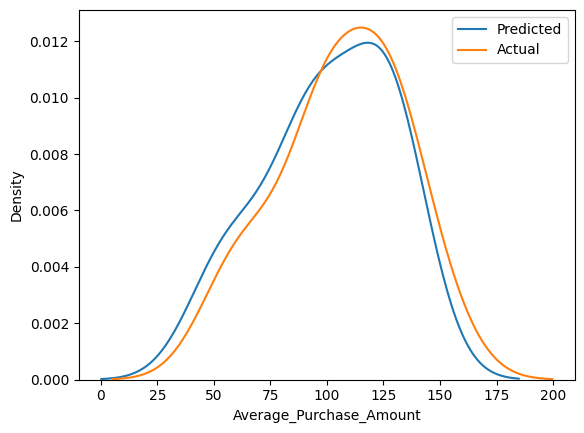

In [16]:
sns.kdeplot(y_dtr_pred,label="Predicted")
sns.kdeplot(y_reg_test,label="Actual")
plt.legend()
plt.show()